In [43]:
import pandas as pd

# Apresentando o dataset
df = pd.read_csv('car_price_dataset.csv')
display(df)

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867
...,...,...,...,...,...,...,...,...,...,...
9995,Kia,Optima,2004,3.7,Diesel,Semi-Automatic,5794,2,4,8884
9996,Chevrolet,Impala,2002,1.4,Electric,Automatic,168000,2,1,6240
9997,BMW,3 Series,2010,3.0,Petrol,Automatic,86664,5,1,9866
9998,Ford,Explorer,2002,1.4,Hybrid,Automatic,225772,4,1,4084


In [44]:
# Verificando o tipo de dado de cada atributo
df.dtypes

Brand               str
Model               str
Year              int64
Engine_Size     float64
Fuel_Type           str
Transmission        str
Mileage           int64
Doors             int64
Owner_Count       int64
Price             int64
dtype: object

In [45]:
# Apresentando se contém dados nulos e a quantidade por coluna
df.isnull().sum()

Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64

In [46]:
# Verificando se os nulos são linhas inteiras vazias ou dados dispersos
linhas_completamente_vazias = df.isnull().all(axis=1).sum()
linhas_com_algum_nulo = df.isnull().any(axis=1).sum()

print(f"Linhas com TODOS os valores nulos (completamente vazias): {linhas_completamente_vazias}")
print(f"Linhas com pelo menos UM valor nulo: {linhas_com_algum_nulo}")

if linhas_completamente_vazias == linhas_com_algum_nulo:
    print("\nCONCLUSÃO: Todos os nulos estão concentrados em linhas inteiras que estão totalmente em branco!")
else:
    print("\nCONCLUSÃO: Existem valores nulos dispersos pelo dataset (alguns dados preenchidos e outros faltando na mesma linha).")

Linhas com TODOS os valores nulos (completamente vazias): 0
Linhas com pelo menos UM valor nulo: 0

CONCLUSÃO: Todos os nulos estão concentrados em linhas inteiras que estão totalmente em branco!


In [47]:
# Removendo as linhas com valores nulos do dataset
df_limpo = df.dropna()

print(f"Número de linhas ANTES da limpeza: {df.shape[0]}")
print(f"Número de linhas DEPOIS da limpeza: {df_limpo.shape[0]}")
print(f"Total de linhas nulas apagadas: {df.shape[0] - df_limpo.shape[0]}\n")

# Verificação final para garantir que não sobrou nenhum nulo
print("Quantidade de nulos após a limpeza:")
print(df_limpo.isnull().sum())

Número de linhas ANTES da limpeza: 10000
Número de linhas DEPOIS da limpeza: 10000
Total de linhas nulas apagadas: 0

Quantidade de nulos após a limpeza:
Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64


In [48]:
# Analisando se os dados numéricos estão normalizados
print("Análise das escalas numéricas ANTES da Normalização:")
colunas_numericas = df_limpo.select_dtypes(include=['int64', 'float64']).columns
colunas_para_normalizar = [col for col in colunas_numericas if col not in ['Price']]

display(df_limpo[colunas_para_normalizar].describe().loc[['min', 'max']])

print("\nCONCLUSÃO: Os dados numéricos NÃO estão normalizados.")

Análise das escalas numéricas ANTES da Normalização:


,Year,Engine_Size,Mileage,Doors,Owner_Count
min,2000.0,1.0,25.0,2.0,1.0
max,2023.0,5.0,299947.0,5.0,5.0



CONCLUSÃO: Os dados numéricos NÃO estão normalizados.


C:\Users\danie\AppData\Local\Temp\ipykernel_14512\1053010119.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_corr.select_dtypes(include=['object']).columns:


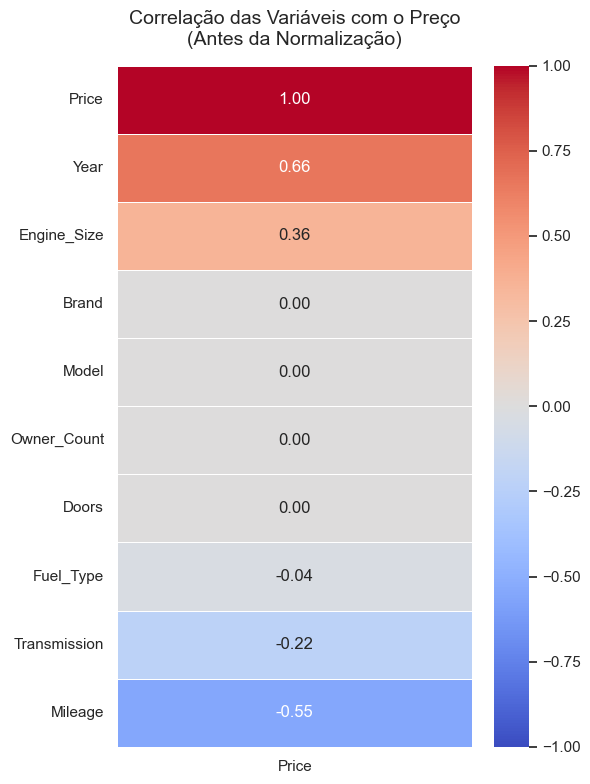

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapa de calor de correlação das variáveis APENAS com o Preço (Antes de Normalizar)
sns.set_theme(style="white")

df_corr = df_limpo.copy()
for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

correlacoes_preco = df_corr.corr()[['Price']].sort_values(by='Price', ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(correlacoes_preco, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, 
            linewidths=0.5, linecolor='white')
plt.title('Correlação das Variáveis com o Preço\n(Antes da Normalização)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


In [50]:
# Normalizando as colunas numéricas MANUALMENTE (sem o uso do scikit-learn)
df_normalizado = df_limpo.copy()

for col in colunas_para_normalizar:
    valor_minimo = df_normalizado[col].min()
    valor_maximo = df_normalizado[col].max()
    df_normalizado[col] = (df_normalizado[col] - valor_minimo) / (valor_maximo - valor_minimo)

print("✅ Dados numéricos normalizados com sucesso (O Preço NÃO foi normalizado)!\n")
colunas_verificacao = colunas_para_normalizar + ['Price']
display(df_normalizado[colunas_verificacao].describe().loc[['min', 'max']])

✅ Dados numéricos normalizados com sucesso (O Preço NÃO foi normalizado)!



,Year,Engine_Size,Mileage,Doors,Owner_Count,Price
min,0.0,0.0,0.0,0.0,0.0,2000.0
max,1.0,1.0,1.0,1.0,1.0,18301.0


C:\Users\danie\AppData\Local\Temp\ipykernel_14512\456346145.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_matriz.select_dtypes(include=['object']).columns:


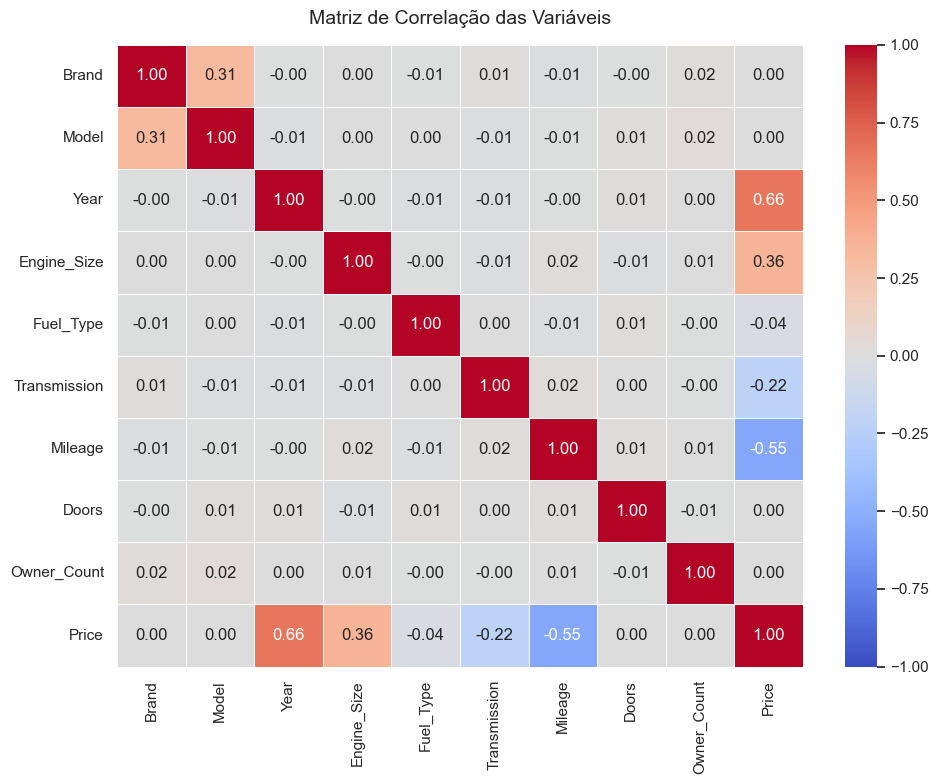

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# MATRIZ DE CORRELAÇÃO DE TODAS AS VARIÁVEIS (Gráfico Quadrado)
sns.set_theme(style="white")

df_matriz = df_limpo.copy()
for col in df_matriz.select_dtypes(include=['object']).columns:
    df_matriz[col] = df_matriz[col].astype('category').cat.codes

matriz_correlacao = df_matriz.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, 
            linewidths=0.5, linecolor='white')
plt.title('Matriz de Correlação das Variáveis', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

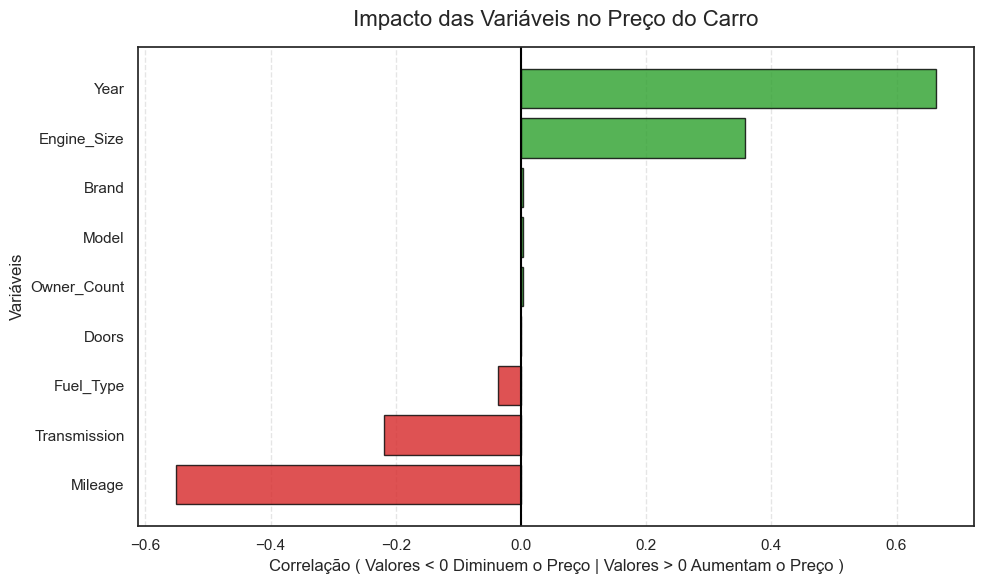

In [52]:
# Gráfico de barras horizontais mostrando o impacto (correlação) de cada variável no Preço
# Variáveis que diminuem o preço ficam à esquerda (vermelho)
# Variáveis que aumentam o preço ficam à direita (verde)

import matplotlib.pyplot as plt

if 'Price' in correlacoes_preco.index:
    corr_plot = correlacoes_preco.drop('Price')
else:
    corr_plot = correlacoes_preco.copy()

corr_plot = corr_plot.sort_values(by='Price')

plt.figure(figsize=(10, 6))
cores = ['#d62728' if x < 0 else '#2ca02c' for x in corr_plot['Price']]

plt.barh(corr_plot.index, corr_plot['Price'], color=cores, edgecolor='black', alpha=0.8)
plt.title('Impacto das Variáveis no Preço do Carro', fontsize=16, pad=15)
plt.xlabel('Correlação ( Valores < 0 Diminuem o Preço | Valores > 0 Aumentam o Preço )', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [53]:
# Removendo as 3 variáveis com correlação irrelevante (praticamente 0)
df_limpo = df_limpo.drop(columns=['Doors', 'Owner_Count', 'Model'])

# Atualizando a variável de correlações para o gráfico não dar erro
correlacoes_preco = correlacoes_preco.drop(index=['Doors', 'Owner_Count', 'Model'], errors='ignore')

print("Variáveis 'Doors', 'Owner_Count' e 'Model' foram removidas com sucesso!")


Variáveis 'Doors', 'Owner_Count' e 'Model' foram removidas com sucesso!


In [54]:
# Apresentando o dataset atualizado (agora sem as colunas Doors, Owner_Count e Model)
print("Formato do dataset após a remoção:", df_limpo.shape)
display(df_limpo.head())


Formato do dataset após a remoção: (10000, 7)


,Brand,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Price
0,Kia,2020,4.2,Diesel,Manual,289944,8501
1,Chevrolet,2012,2.0,Hybrid,Automatic,5356,12092
2,Mercedes,2020,4.2,Diesel,Automatic,231440,11171
3,Audi,2023,2.0,Electric,Manual,160971,11780
4,Volkswagen,2003,2.6,Hybrid,Semi-Automatic,286618,2867


C:\Users\danie\AppData\Local\Temp\ipykernel_14512\3305403806.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_df.select_dtypes(include=['object']).columns:


Treinamento concluído em 59 épocas!
EQM Final no Treino: 0.003155



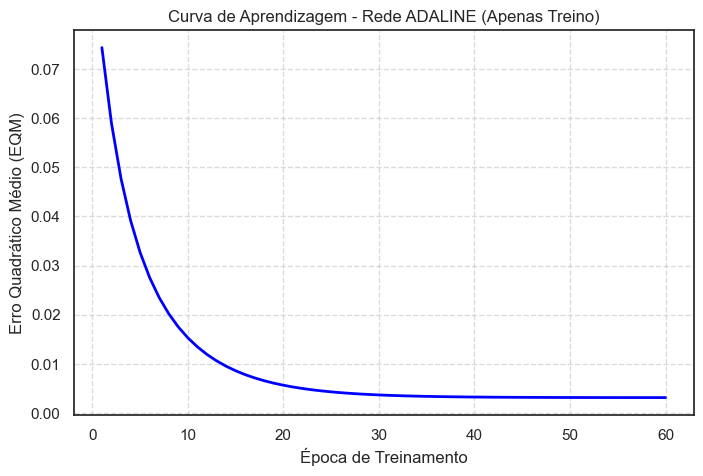

EQM no conjunto de Teste (Normalizado): 0.003238

--- Primeiras 10 predições no conjunto de TESTE (Linhas 800 a 810) ---


,Preço Real,Preço Predito (Adaline),Diferença
0,6012,6656.16,-644.16
1,4008,3577.89,430.11
2,9379,9576.76,-197.76
3,9617,10674.61,-1057.61
4,6843,7593.00,-750.00
5,7438,8539.84,-1101.84
6,13901,14941.00,-1040.00
7,3441,3684.91,-243.91
8,6354,4921.19,1432.81
9,11567,10939.48,627.52


In [55]:
# ==================================================================
# PREDIÇÃO DE PREÇO UTILIZANDO REDE NEURAL ADALINE (REGRA DELTA)
# Parâmetros extraídos do documento Adaline.docx:
# - x0 = -1 (bias)
# - Inicialização de pesos aleatória (0 a 1)
# - Taxa de aprendizado = 0.0025
# - Precisão = 10^-6
# - Conjunto: 800 treino / 200 teste
# ==================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparação dos dados
# Removendo as variáveis que tinham correlação zero com Price
features = [c for c in df_limpo.columns if c not in ['Price', 'Doors', 'Owner_Count', 'Model']]
X_df = df_limpo[features].copy()

# Transformar variáveis categóricas em numéricas para a rede neural
for col in X_df.select_dtypes(include=['object']).columns:
    X_df[col] = X_df[col].astype('category').cat.codes

# Normalização de X (Min-Max) para a rede Adaline convergir
X_norm = (X_df - X_df.min()) / (X_df.max() - X_df.min())
X_arr = X_norm.values

# Normalização do Y (Preço)
y_arr = df_limpo['Price'].values
preco_min = y_arr.min()
preco_max = y_arr.max()
y_norm = (y_arr - preco_min) / (preco_max - preco_min)

# Inserindo o termo de bias x0 = -1 na matriz de entrada X
X_bias = np.c_[np.full(X_arr.shape[0], -1), X_arr]

# Divisão de Treino (800) e Teste (200)
X_treino = X_bias[:800]
y_treino = y_norm[:800]

X_teste = X_bias[800:1000]
y_teste = y_norm[800:1000]
y_teste_reais = y_arr[800:1000]

# 2. Parâmetros da Rede ADALINE
taxa_aprendizado = 0.0025
precisao = 1e-6
max_epocas = 1500

# Inicializando pesos aleatórios entre 0 e 1
np.random.seed(42)
w = np.random.rand(X_treino.shape[1])

erros_epocas = []
epoca = 0
eqm_anterior = float('inf')

# 3. Treinamento da Rede ADALINE com Regra Delta (Apenas nos 800 primeiros)
while epoca < max_epocas:
    for i in range(len(X_treino)):
        u = np.dot(w, X_treino[i])
        erro = y_treino[i] - u
        
        # Atualização dos pesos (w = w + taxa * erro * x)
        w = w + taxa_aprendizado * erro * X_treino[i]
    
    # Cálculo do EQM ao final da época
    u_todos = np.dot(X_treino, w)
    erros_amostras = y_treino - u_todos
    eqm_atual = np.mean(erros_amostras**2)
    erros_epocas.append(eqm_atual)
    
    if abs(eqm_anterior - eqm_atual) < precisao:
        break
        
    eqm_anterior = eqm_atual
    epoca += 1

print(f"Treinamento concluído em {epoca} épocas!")
print(f"EQM Final no Treino: {eqm_atual:.6f}\n")

# 4. Gráfico do EQM em função da Época
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(erros_epocas) + 1), erros_epocas, color='blue', linewidth=2)
plt.title('Curva de Aprendizagem - Rede ADALINE (Apenas Treino)')
plt.xlabel('Época de Treinamento')
plt.ylabel('Erro Quadrático Médio (EQM)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 5. Avaliação no conjunto de Teste (200 registros)
predicoes_teste_norm = np.dot(X_teste, w)
predicoes_teste_reais = predicoes_teste_norm * (preco_max - preco_min) + preco_min

# Calculando EQM no Teste
erros_teste_norm = y_teste - predicoes_teste_norm
eqm_teste = np.mean(erros_teste_norm**2)
print(f"EQM no conjunto de Teste (Normalizado): {eqm_teste:.6f}\n")

# Mostrando algumas predições do Teste em Reais
resultados_teste = pd.DataFrame({
    'Preço Real': y_teste_reais[:10],
    'Preço Predito (Adaline)': predicoes_teste_reais[:10].round(2),
    'Diferença': (y_teste_reais[:10] - predicoes_teste_reais[:10]).round(2)
})

print("--- Primeiras 10 predições no conjunto de TESTE (Linhas 800 a 810) ---")
display(resultados_teste)


C:\Users\danie\AppData\Local\Temp\ipykernel_14512\2905968700.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_df.select_dtypes(include=['object']).columns:


Treinamento PMC concluído em 451 épocas!
EQM Final no Treinamento: 0.000622



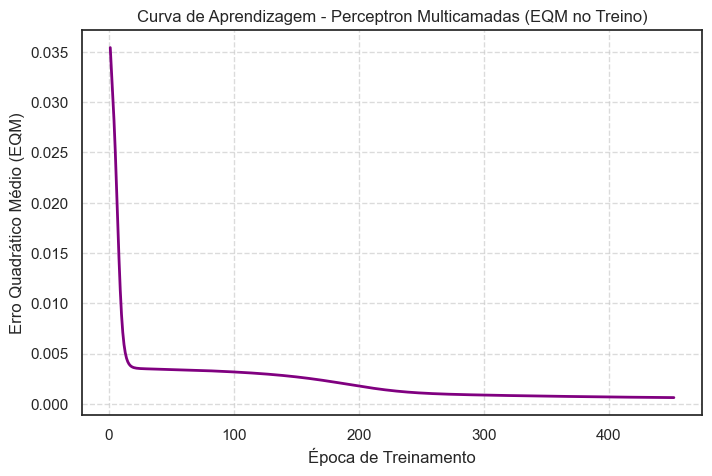

EQM no conjunto de Teste (Normalizado): 0.000618

--- Primeiras 10 predições no conjunto de TESTE (PMC) ---


,Preço Real,Preço Predito (PMC),Diferença
0,6012,5913.86,98.14
1,4008,4264.13,-256.13
2,9379,9928.82,-549.82
3,9617,9457.81,159.19
4,6843,6728.51,114.49
5,7438,7150.27,287.73
6,13901,13492.88,408.12
7,3441,4101.12,-660.12
8,6354,5668.39,685.61
9,11567,12028.68,-461.68


In [56]:
# ==================================================================
# PREDIÇÃO DE PREÇO UTILIZANDO PERCEPTRON MULTICAMADAS (PMC)
# Algoritmo: Backpropagation (Regra Delta Generalizada)
# Parâmetros baseados no arquivo PMC1.docx
# ==================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparação e Separação (800 treino / 200 teste)
features = [c for c in df_limpo.columns if c not in ['Price', 'Doors', 'Owner_Count', 'Model']]
X_df = df_limpo[features].copy()

# Transformar categorias em números
for col in X_df.select_dtypes(include=['object']).columns:
    X_df[col] = X_df[col].astype('category').cat.codes

# Normalização de X
X_norm = (X_df - X_df.min()) / (X_df.max() - X_df.min())
X_arr = X_norm.values

# Normalização do Y (Preço) entre 0 e 1, pois a Logística (Sigmoide) gera saídas entre 0 e 1
y_arr = df_limpo['Price'].values
preco_min = y_arr.min()
preco_max = y_arr.max()
y_norm = (y_arr - preco_min) / (preco_max - preco_min)

# Bias x0 = -1 inserido na entrada
X_bias = np.c_[np.full(X_arr.shape[0], -1), X_arr]

X_treino = X_bias[:800]
y_treino = y_norm[:800]
X_teste = X_bias[800:1000]
y_teste = y_norm[800:1000]
y_teste_reais = y_arr[800:1000]

# 2. Arquitetura da Rede e Funções de Ativação
def logistica(x):
    x = np.clip(x, -500, 500) # Evita travamento matemático (overflow)
    return 1 / (1 + np.exp(-x))

def logistica_derivada(x):
    sig = logistica(x)
    return sig * (1 - sig)

taxa_aprendizado = 0.1
precisao = 1e-6
max_epocas = 1500

n_entradas = X_treino.shape[1] # Incluindo bias
n_ocultos = 10                 # 10 neurônios na camada oculta
n_saida = 1

np.random.seed(42)
# Pesos Iniciais: Aleatórios entre 0 e 1
W_oculta = np.random.rand(n_entradas, n_ocultos)

# A camada oculta também emite um bias (-1) para a camada de saída
W_saida = np.random.rand(n_ocultos + 1, n_saida)

erros_epocas = []
epoca = 0
eqm_anterior = float('inf')

# 3. Treinamento (Algoritmo Backpropagation)
while epoca < max_epocas:
    
    # Processa cada amostra do conjunto de treinamento
    for i in range(len(X_treino)):
        x_in = X_treino[i:i+1] # Padrão atual de entrada (formato de matriz linha)
        y_desejado = y_treino[i]
        
        # --- ETAPA FORWARD ---
        # Camada Oculta
        net_oculta = np.dot(x_in, W_oculta)
        out_oculta = logistica(net_oculta)
        
        # Inserindo o termo de bias (-1) na saída da camada oculta para ir à saída
        out_oculta_bias = np.c_[np.array([[-1]]), out_oculta]
        
        # Camada de Saída
        net_saida = np.dot(out_oculta_bias, W_saida)
        out_saida = logistica(net_saida)
        
        # --- ETAPA BACKWARD (Cálculo dos Gradientes e Erros) ---
        erro = y_desejado - out_saida
        
        # Gradiente local da camada de saída
        delta_saida = erro * logistica_derivada(net_saida)
        
        # Gradiente local da camada oculta (desconsidera o peso referente ao bias)
        W_saida_sem_bias = W_saida[1:, :] 
        delta_oculta = np.dot(delta_saida, W_saida_sem_bias.T) * logistica_derivada(net_oculta)
        
        # --- ATUALIZAÇÃO DOS PESOS (Regra Delta Generalizada) ---
        W_saida = W_saida + taxa_aprendizado * np.dot(out_oculta_bias.T, delta_saida)
        W_oculta = W_oculta + taxa_aprendizado * np.dot(x_in.T, delta_oculta)
    
    # Cálculo do EQM Global da época para checar a Precisão
    net_oculta_all = np.dot(X_treino, W_oculta)
    out_oculta_all = logistica(net_oculta_all)
    out_oculta_bias_all = np.c_[np.full(len(X_treino), -1), out_oculta_all]
    out_saida_all = logistica(np.dot(out_oculta_bias_all, W_saida))
    
    eqm_atual = np.mean((y_treino.reshape(-1, 1) - out_saida_all)**2)
    erros_epocas.append(eqm_atual)
    
    # Critério de Parada
    if abs(eqm_anterior - eqm_atual) < precisao:
        break
        
    eqm_anterior = eqm_atual
    epoca += 1

print(f"Treinamento PMC concluído em {epoca} épocas!")
print(f"EQM Final no Treinamento: {eqm_atual:.6f}\n")

# 4. Gráfico do EQM em função da Época
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(erros_epocas) + 1), erros_epocas, color='purple', linewidth=2)
plt.title('Curva de Aprendizagem - Perceptron Multicamadas (EQM no Treino)')
plt.xlabel('Época de Treinamento')
plt.ylabel('Erro Quadrático Médio (EQM)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 5. Avaliação do Modelo no Conjunto de TESTE
net_oculta_teste = np.dot(X_teste, W_oculta)
out_oculta_teste = logistica(net_oculta_teste)
out_oculta_bias_teste = np.c_[np.full(len(X_teste), -1), out_oculta_teste]
out_saida_teste = logistica(np.dot(out_oculta_bias_teste, W_saida))

# Desnormalizando as predições para obtermos o valor financeiro do Carro
predicoes_teste_reais = out_saida_teste.flatten() * (preco_max - preco_min) + preco_min

# EQM Normalizado do Teste
erros_teste_norm = y_teste - out_saida_teste.flatten()
eqm_teste = np.mean(erros_teste_norm**2)
print(f"EQM no conjunto de Teste (Normalizado): {eqm_teste:.6f}\n")

# Visualização Real - Primeiros 10 testes
resultados_teste_pmc = pd.DataFrame({
    'Preço Real': y_teste_reais[:10],
    'Preço Predito (PMC)': predicoes_teste_reais[:10].round(2),
    'Diferença': (y_teste_reais[:10] - predicoes_teste_reais[:10]).round(2)
})

print("--- Primeiras 10 predições no conjunto de TESTE (PMC) ---")
display(resultados_teste_pmc)


C:\Users\danie\AppData\Local\Temp\ipykernel_14512\3838526886.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_df.select_dtypes(include=['object']).columns:


Treinamento PMC COM MOMENTUM concluído em 128 épocas!
Tempo de Processamento: 22.87 segundos
EQM Final no Treinamento: 0.000317



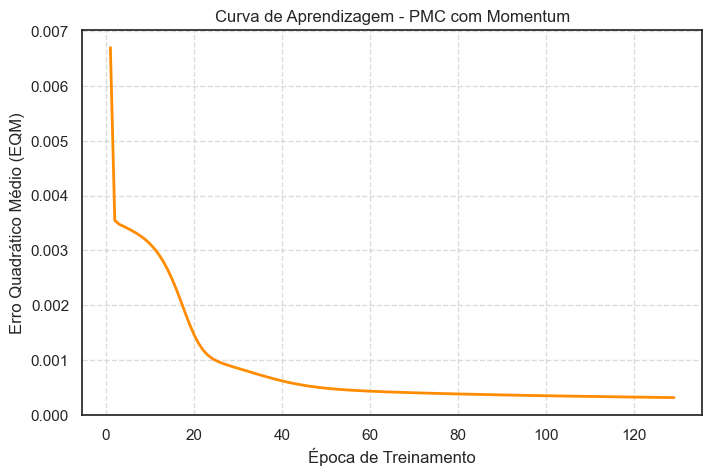

EQM no conjunto de Teste (Normalizado): 0.000302

--- Primeiras 10 predições no TESTE (PMC com Momentum) ---


,Preço Real,Preço Predito (PMC Momentum),Diferença
0,6012,5733.49,278.51
1,4008,4349.99,-341.99
2,9379,9614.55,-235.55
3,9617,9534.16,82.84
4,6843,6725.02,117.98
5,7438,7204.99,233.01
6,13901,13527.05,373.95
7,3441,4046.63,-605.63
8,6354,5867.89,486.11
9,11567,11965.58,-398.58


In [57]:
# ==================================================================
# PREDIÇÃO DE PREÇO UTILIZANDO PERCEPTRON MULTICAMADAS (PMC) COM MOMENTUM
# Algoritmo: Backpropagation com Momentum
# Parâmetros baseados no arquivo PMC2.docx
# ==================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# 1. Preparação (800 treino / 200 teste)
features = [c for c in df_limpo.columns if c not in ['Price', 'Doors', 'Owner_Count', 'Model']]
X_df = df_limpo[features].copy()

for col in X_df.select_dtypes(include=['object']).columns:
    X_df[col] = X_df[col].astype('category').cat.codes

X_norm = (X_df - X_df.min()) / (X_df.max() - X_df.min())
X_arr = X_norm.values

y_arr = df_limpo['Price'].values
preco_min = y_arr.min()
preco_max = y_arr.max()
y_norm = (y_arr - preco_min) / (preco_max - preco_min)

X_bias = np.c_[np.full(X_arr.shape[0], -1), X_arr]

X_treino = X_bias[:800]
y_treino = y_norm[:800]
X_teste = X_bias[800:1000]
y_teste = y_norm[800:1000]
y_teste_reais = y_arr[800:1000]

# 2. Arquitetura e Funções
def logistica(x):
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

def logistica_derivada(x):
    sig = logistica(x)
    return sig * (1 - sig)

taxa_aprendizado = 0.1
fator_momentum = 0.9
precisao = 1e-6
max_epocas = 1500

n_entradas = X_treino.shape[1] 
n_ocultos = 15                 # 15 neurônios na oculta (baseado no PMC2)
n_saida = 1

np.random.seed(42)
W_oculta = np.random.rand(n_entradas, n_ocultos)
W_saida = np.random.rand(n_ocultos + 1, n_saida)

# Matrizes para guardar o Delta dos pesos da época anterior (Necessário para o Momentum)
delta_W_oculta_ant = np.zeros_like(W_oculta)
delta_W_saida_ant = np.zeros_like(W_saida)

erros_epocas = []
epoca = 0
eqm_anterior = float('inf')

# Marcando o tempo de início
start_time = time.time()

# 3. Treinamento (Backpropagation COM MOMENTUM)
while epoca < max_epocas:
    for i in range(len(X_treino)):
        x_in = X_treino[i:i+1]
        y_desejado = y_treino[i]
        
        # --- FORWARD ---
        net_oculta = np.dot(x_in, W_oculta)
        out_oculta = logistica(net_oculta)
        
        out_oculta_bias = np.c_[np.array([[-1]]), out_oculta]
        
        net_saida = np.dot(out_oculta_bias, W_saida)
        out_saida = logistica(net_saida)
        
        # --- BACKWARD ---
        erro = y_desejado - out_saida
        delta_saida = erro * logistica_derivada(net_saida)
        
        W_saida_sem_bias = W_saida[1:, :] 
        delta_oculta = np.dot(delta_saida, W_saida_sem_bias.T) * logistica_derivada(net_oculta)
        
        # --- ATUALIZAÇÃO COM MOMENTUM ---
        # Formula: Peso = Peso + (Taxa * Gradiente) + (Alfa * DeltaAnterior)
        
        grad_saida = taxa_aprendizado * np.dot(out_oculta_bias.T, delta_saida)
        atualizacao_W_saida = grad_saida + (fator_momentum * delta_W_saida_ant)
        W_saida = W_saida + atualizacao_W_saida
        delta_W_saida_ant = atualizacao_W_saida
        
        grad_oculta = taxa_aprendizado * np.dot(x_in.T, delta_oculta)
        atualizacao_W_oculta = grad_oculta + (fator_momentum * delta_W_oculta_ant)
        W_oculta = W_oculta + atualizacao_W_oculta
        delta_W_oculta_ant = atualizacao_W_oculta
    
    # EQM Global
    net_oculta_all = np.dot(X_treino, W_oculta)
    out_oculta_all = logistica(net_oculta_all)
    out_oculta_bias_all = np.c_[np.full(len(X_treino), -1), out_oculta_all]
    out_saida_all = logistica(np.dot(out_oculta_bias_all, W_saida))
    
    eqm_atual = np.mean((y_treino.reshape(-1, 1) - out_saida_all)**2)
    erros_epocas.append(eqm_atual)
    
    if abs(eqm_anterior - eqm_atual) < precisao:
        break
        
    eqm_anterior = eqm_atual
    epoca += 1

tempo_treino = time.time() - start_time

print(f"Treinamento PMC COM MOMENTUM concluído em {epoca} épocas!")
print(f"Tempo de Processamento: {tempo_treino:.2f} segundos")
print(f"EQM Final no Treinamento: {eqm_atual:.6f}\n")

# 4. Gráfico da Curva de Aprendizagem
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(erros_epocas) + 1), erros_epocas, color='darkorange', linewidth=2)
plt.title('Curva de Aprendizagem - PMC com Momentum')
plt.xlabel('Época de Treinamento')
plt.ylabel('Erro Quadrático Médio (EQM)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 5. Avaliação no TESTE
net_oculta_teste = np.dot(X_teste, W_oculta)
out_oculta_teste = logistica(net_oculta_teste)
out_oculta_bias_teste = np.c_[np.full(len(X_teste), -1), out_oculta_teste]
out_saida_teste = logistica(np.dot(out_oculta_bias_teste, W_saida))

predicoes_teste_reais = out_saida_teste.flatten() * (preco_max - preco_min) + preco_min

erros_teste_norm = y_teste - out_saida_teste.flatten()
eqm_teste = np.mean(erros_teste_norm**2)
print(f"EQM no conjunto de Teste (Normalizado): {eqm_teste:.6f}\n")

resultados_teste_pmc2 = pd.DataFrame({
    'Preço Real': y_teste_reais[:10],
    'Preço Predito (PMC Momentum)': predicoes_teste_reais[:10].round(2),
    'Diferença': (y_teste_reais[:10] - predicoes_teste_reais[:10]).round(2)
})

print("--- Primeiras 10 predições no TESTE (PMC com Momentum) ---")
display(resultados_teste_pmc2)



--- Treinando Rede 1 (Atrasos p=5, Ocultos=5) ---
Treino concluído: 113 épocas | EQM Final: 0.034568


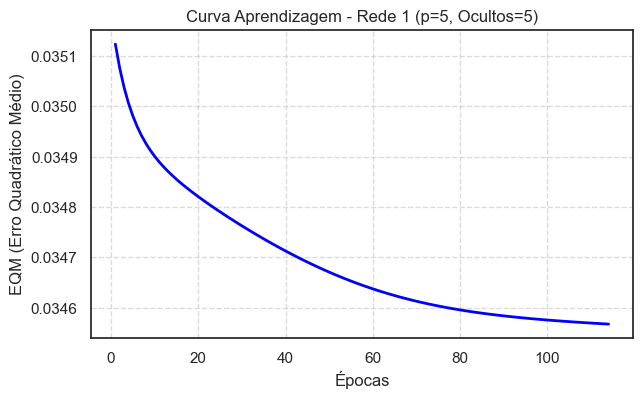

TESTE - Erro Relativo Médio: 35.5835%
TESTE - Variância do Erro: 2702.6882

---------------------------------------------------------------------------
   PREVISÕES: 10 PRIMEIRAS AMOSTRAS DO TESTE (Rede 1)
---------------------------------------------------------------------------


,Linha do Dataframe,Preço Real,Previsão Rede 1,Erro (R$)
0,505,"9,942.00","8,701.02","1,240.98"
1,506,"5,139.00","9,139.31","4,000.31"
2,507,"11,399.00","9,050.53","2,348.47"
3,508,"7,193.00","8,718.62","1,525.62"
4,509,"10,801.00","9,213.13","1,587.87"
5,510,"11,714.00","8,714.79","2,999.21"
6,511,"9,333.00","9,304.72",28.28
7,512,"15,458.00","8,733.68","6,724.32"
8,513,"11,848.00","9,122.82","2,725.18"
9,514,"5,005.00","9,038.67","4,033.67"





--- Treinando Rede 2 (Atrasos p=10, Ocultos=10) ---
Treino concluído: 2 épocas | EQM Final: 0.035012


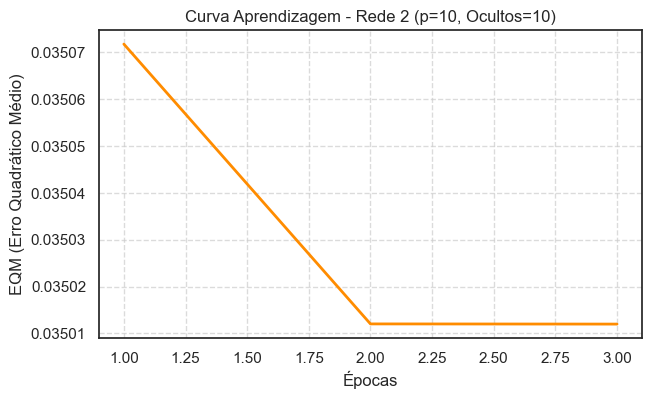

TESTE - Erro Relativo Médio: 35.6359%
TESTE - Variância do Erro: 2675.1534

---------------------------------------------------------------------------
   PREVISÕES: 10 PRIMEIRAS AMOSTRAS DO TESTE (Rede 2)
---------------------------------------------------------------------------


,Linha do Dataframe,Preço Real,Previsão Rede 2,Erro (R$)
0,510,"11,714.00","9,041.65","2,672.35"
1,511,"9,333.00","8,984.33",348.67
2,512,"15,458.00","9,165.28","6,292.72"
3,513,"11,848.00","9,071.27","2,776.73"
4,514,"5,005.00","9,082.26","4,077.26"
5,515,"10,049.00","8,992.50","1,056.50"
6,516,"9,986.00","8,871.98","1,114.02"
7,517,"9,815.00","9,193.83",621.17
8,518,"13,261.00","9,105.28","4,155.72"
9,519,"5,542.00","9,058.02","3,516.02"





--- Treinando Rede 3 (Atrasos p=15, Ocultos=20) ---
Treino concluído: 1500 épocas | EQM Final: 0.025297


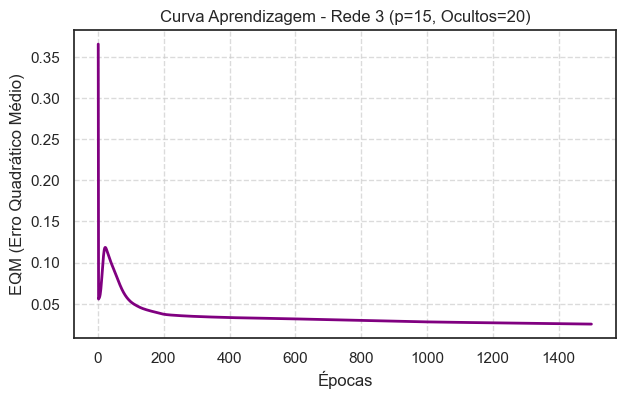

TESTE - Erro Relativo Médio: 41.6144%
TESTE - Variância do Erro: 2684.4804

---------------------------------------------------------------------------
   PREVISÕES: 10 PRIMEIRAS AMOSTRAS DO TESTE (Rede 3)
---------------------------------------------------------------------------


,Linha do Dataframe,Preço Real,Previsão Rede 3,Erro (R$)
0,515,"10,049.00","4,453.84","5,595.16"
1,516,"9,986.00","5,497.74","4,488.26"
2,517,"9,815.00","10,152.87",337.87
3,518,"13,261.00","6,846.70","6,414.30"
4,519,"5,542.00","9,766.70","4,224.70"
5,520,"10,724.00","9,530.91","1,193.09"
6,521,"9,700.00","9,230.25",469.75
7,522,"11,697.00","8,727.78","2,969.22"
8,523,"8,914.00","8,042.96",871.04
9,524,"2,068.00","9,692.56","7,624.56"


In [58]:
# ==================================================================
# TDNN (TIME DELAY) - TREINAMENTO E TESTE DAS 3 REDES
# (Rode esta célula logo após o seu bloco que cria o df_limpo)
# ==================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display 

# 1. Puxando a variável exata do seu df_limpo traduzido
serie_preco = df_limpo['Price'].values
preco_min, preco_max = serie_preco.min(), serie_preco.max()
serie_norm = (serie_preco - preco_min) / (preco_max - preco_min)

def criar_janelas(serie, p):
    X, Y = [], []
    for i in range(len(serie) - p):
        X.append(serie[i : i + p])
        Y.append(serie[i + p])
    return np.array(X), np.array(Y)

def logistica(x):
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

def logistica_derivada(x):
    sig = logistica(x)
    return sig * (1 - sig)

taxa_aprendizado = 0.1
fator_momentum = 0.8
precisao = 0.5e-6
max_epocas = 1500

configuracoes = [
    {'nome': 'Rede 1', 'p': 5, 'n_ocultos': 5, 'cor': 'blue'},
    {'nome': 'Rede 2', 'p': 10, 'n_ocultos': 10, 'cor': 'darkorange'},
    {'nome': 'Rede 3', 'p': 15, 'n_ocultos': 20, 'cor': 'purple'}
]

for config in configuracoes:
    print(f"\n=======================================================")
    print(f"--- Treinando {config['nome']} (Atrasos p={config['p']}, Ocultos={config['n_ocultos']}) ---")
    p = config['p']
    n_ocultos = config['n_ocultos']
    
    X_tdnn, y_tdnn = criar_janelas(serie_norm, p)
    X_bias = np.c_[np.full(X_tdnn.shape[0], -1), X_tdnn]

    # Cortando para treino (500 amostras) e teste
    X_treino, y_treino = X_bias[:500], y_tdnn[:500]
    X_teste, y_teste = X_bias[500:700], y_tdnn[500:700]
    
    n_entradas = X_treino.shape[1] 
    n_saida = 1

    np.random.seed(42)
    W_oculta = np.random.rand(n_entradas, n_ocultos)
    W_saida = np.random.rand(n_ocultos + 1, n_saida)

    delta_W_oculta_ant = np.zeros_like(W_oculta)
    delta_W_saida_ant = np.zeros_like(W_saida)

    erros_epocas, epoca, eqm_anterior = [], 0, float('inf')

    # Fase de Treinamento
    while epoca < max_epocas:
        for i in range(len(X_treino)):
            x_in, y_desejado = X_treino[i:i+1], y_treino[i]
            
            # Forward
            net_oculta = np.dot(x_in, W_oculta)
            out_oculta = logistica(net_oculta)
            out_oculta_bias = np.c_[np.array([[-1]]), out_oculta]
            
            net_saida = np.dot(out_oculta_bias, W_saida)
            out_saida = logistica(net_saida)
            
            # Backward
            erro = y_desejado - out_saida
            delta_saida = erro * logistica_derivada(net_saida)
            W_saida_sem_bias = W_saida[1:, :] 
            delta_oculta = np.dot(delta_saida, W_saida_sem_bias.T) * logistica_derivada(net_oculta)
            
            # Atualização de Pesos (Momentum)
            grad_saida = taxa_aprendizado * np.dot(out_oculta_bias.T, delta_saida)
            atualizacao_W_saida = grad_saida + (fator_momentum * delta_W_saida_ant)
            W_saida += atualizacao_W_saida
            delta_W_saida_ant = atualizacao_W_saida
            
            grad_oculta = taxa_aprendizado * np.dot(x_in.T, delta_oculta)
            atualizacao_W_oculta = grad_oculta + (fator_momentum * delta_W_oculta_ant)
            W_oculta += atualizacao_W_oculta
            delta_W_oculta_ant = atualizacao_W_oculta
        
        net_oculta_all = logistica(np.dot(X_treino, W_oculta))
        out_saida_all = logistica(np.dot(np.c_[np.full(len(X_treino), -1), net_oculta_all], W_saida))
        
        eqm_atual = np.mean((y_treino.reshape(-1, 1) - out_saida_all)**2)
        erros_epocas.append(eqm_atual)
        
        if abs(eqm_anterior - eqm_atual) < precisao:
            break
        eqm_anterior = eqm_atual
        epoca += 1

    print(f"Treino concluído: {epoca} épocas | EQM Final: {eqm_atual:.6f}")

    # Gráfico
    plt.figure(figsize=(7, 4))
    plt.plot(range(1, len(erros_epocas) + 1), erros_epocas, color=config['cor'], linewidth=2)
    plt.title(f"Curva Aprendizagem - {config['nome']} (p={p}, Ocultos={n_ocultos})")
    plt.xlabel('Épocas')
    plt.ylabel('EQM (Erro Quadrático Médio)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # Previsões no Teste e Desnormalização
    net_oculta_teste = logistica(np.dot(X_teste, W_oculta))
    out_saida_teste = logistica(np.dot(np.c_[np.full(len(X_teste), -1), net_oculta_teste], W_saida))

    pred_teste_reais = out_saida_teste.flatten() * (preco_max - preco_min) + preco_min
    y_teste_reais = y_teste * (preco_max - preco_min) + preco_min

    erros_relativos = abs(y_teste_reais - pred_teste_reais) / y_teste_reais * 100
    print(f"TESTE - Erro Relativo Médio: {np.mean(erros_relativos):.4f}%")
    print(f"TESTE - Variância do Erro: {np.var(erros_relativos):.4f}\n")

    # ==================================================================
    # TABELA COM OS 10 PRIMEIROS CARROS DO TESTE (Mostrando a Linha CSV)
    # ==================================================================
    qtd_carros = 10
    resultados_rede = []

    for j in range(qtd_carros):
        # A linha exata do CSV é o índice de corte do teste (500) + os atrasos (p) + o índice atual (j)
        linha_csv = 500 + p + j 
        
        preco_real = y_teste_reais[j]
        preco_prev = pred_teste_reais[j]
        erro_abs = abs(preco_real - preco_prev)
        
        resultados_rede.append({
            "Linha do Dataframe": linha_csv,
            "Preço Real": preco_real,
            f"Previsão {config['nome']}": preco_prev,
            "Erro (R$)": erro_abs
        })

    df_res = pd.DataFrame(resultados_rede)
    
    # Formatando colunas para dinheiro
    for col in ["Preço Real", f"Previsão {config['nome']}", "Erro (R$)"]:
        df_res[col] = df_res[col].apply("{:,.2f}".format)
        
    print("-" * 75)
    print(f"   PREVISÕES: 10 PRIMEIRAS AMOSTRAS DO TESTE ({config['nome']})")
    print("-" * 75)
    display(df_res)
    print("\n")

Treinando Rede 1 (Subajuste)...
Treinando Rede 2 (Ideal)...
Treinando Rede 3 (Sobreajuste)...

-------------------------------------------
--- Resultados no Conjunto de Teste ---
-------------------------------------------
Rede 1 (Subajuste)   - MSE: 1,369,049.02
Rede 2 (Ideal)       - MSE: 3,687,466.78
Rede 3 (Sobreajuste) - MSE: 6,511,116.01


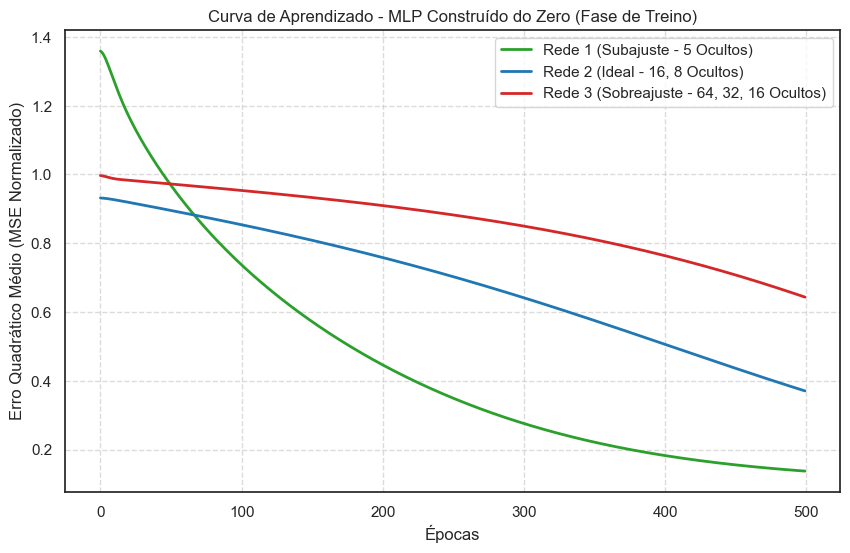

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# BLOCO 1: Pré-processamento Manual (Sem sklearn)
# ---------------------------------------------------------

# Leia o CSV (Ajuste o diretório caso seja necessário)
df = pd.read_csv('car_price_dataset.csv')

# Mapeamento do Tipo_Combustivel
fuel_mapping = {'Petrol': 0, 'Diesel': 1, 'Electric': 2, 'Hybrid': 3}
df['Fuel_Type'] = df['Fuel_Type'].map(fuel_mapping)

# Separar X e y. Usando as colunas disponíveis (substituindo Cavalos por Portas)
X = df[['Year', 'Engine_Size', 'Fuel_Type', 'Mileage', 'Owner_Count', 'Doors']].values
y = df['Price'].values.reshape(-1, 1)

# Normalização Z-Score pura (Numpy) para X
medias = np.mean(X, axis=0)
desvios = np.std(X, axis=0)
desvios[desvios == 0] = 1e-8 # Evitar divisão por zero
X_norm = (X - medias) / desvios

# Normalizar o Y (Recomendado para estabilidade do backprop)
media_y = np.mean(y)
desvio_y = np.std(y)
y_norm = (y - media_y) / desvio_y

# Embaralhar e dividir os dados (Treino 80%, Teste 20%)
np.random.seed(42)
indices = np.random.permutation(len(X_norm))
corte = int(0.8 * len(X_norm))

idx_treino, idx_teste = indices[:corte], indices[corte:]

X_treino, X_teste = X_norm[idx_treino], X_norm[idx_teste]
y_treino, y_teste = y_norm[idx_treino], y_norm[idx_teste]


# ---------------------------------------------------------
# BLOCO 2: A Classe da Rede Neural
# ---------------------------------------------------------
class RedeNeuralNumpy:
    def __init__(self, topologia, taxa_aprendizado=0.005, momentum=0.8):
        self.topologia = topologia
        self.lr = taxa_aprendizado
        self.momentum = momentum
        self.pesos = []
        self.vieses = []
        self.v_pesos = [] # Velocidade do momentum para pesos
        self.v_vieses = [] # Velocidade do momentum para vieses
        
        # Inicialização "He" adaptada para evitar vanishing gradients
        for i in range(len(topologia) - 1):
            W = np.random.randn(topologia[i], topologia[i+1]) * np.sqrt(2. / topologia[i])
            b = np.zeros((1, topologia[i+1]))
            self.pesos.append(W)
            self.vieses.append(b)
            self.v_pesos.append(np.zeros_like(W))
            self.v_vieses.append(np.zeros_like(b))

    def _sigmoid(self, z):
        # Clip limita os valores de z para evitar RuntimeWarning: overflow em np.exp
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))
    
    def _derivada_sigmoid(self, a):
        # Derivada assumindo que "a" já é a ativação (a = sigmoid(z))
        return a * (1.0 - a)

    def forward(self, X):
        ativacoes = [X]
        # Camadas ocultas (Ativação Sigmoid)
        for i in range(len(self.pesos) - 1):
            z = np.dot(ativacoes[-1], self.pesos[i]) + self.vieses[i]
            a = self._sigmoid(z)
            ativacoes.append(a)
            
        # Camada de saída (Linear, sem ativação, pois prevê valores contínuos)
        z_saida = np.dot(ativacoes[-1], self.pesos[-1]) + self.vieses[-1]
        ativacoes.append(z_saida)
        return ativacoes

    def backward(self, ativacoes, y_verdadeiro):
        m = y_verdadeiro.shape[0]
        
        # Erro da camada linear de saída: Derivada de z é 1 -> Delta_L = (A_L - Y)
        delta = (ativacoes[-1] - y_verdadeiro)
        
        grad_pesos = []
        grad_vieses = []
        
        # Gradientes da camada de saída
        grad_W = np.dot(ativacoes[-2].T, delta) / m
        grad_b = np.sum(delta, axis=0, keepdims=True) / m
        grad_pesos.append(grad_W)
        grad_vieses.append(grad_b)
        
        # Backpropagation das camadas ocultas
        for i in range(len(self.pesos) - 2, -1, -1):
            delta = np.dot(delta, self.pesos[i+1].T) * self._derivada_sigmoid(ativacoes[i+1])
            grad_W = np.dot(ativacoes[i].T, delta) / m
            grad_b = np.sum(delta, axis=0, keepdims=True) / m
            grad_pesos.insert(0, grad_W)
            grad_vieses.insert(0, grad_b)
            
        # Atualização de Pesos com fator Momentum
        for i in range(len(self.pesos)):
            self.v_pesos[i] = (self.momentum * self.v_pesos[i]) + (self.lr * grad_pesos[i])
            self.v_vieses[i] = (self.momentum * self.v_vieses[i]) + (self.lr * grad_vieses[i])
            
            self.pesos[i] -= self.v_pesos[i]
            self.vieses[i] -= self.v_vieses[i]
            
    def treinar(self, X, y, epocas):
        historico_mse = []
        for _ in range(epocas):
            ativacoes = self.forward(X)
            self.backward(ativacoes, y)
            
            # Cálculo e registro do Mean Squared Error (MSE)
            mse = np.mean((ativacoes[-1] - y) ** 2)
            historico_mse.append(mse)
        return historico_mse


# ---------------------------------------------------------
# BLOCO 3: O Experimento de Topologias
# ---------------------------------------------------------
# Temos 6 features de input e 1 de output (Preço).
topologia_rede1 = [6, 5, 1] 
topologia_rede2 = [6, 16, 8, 1]
topologia_rede3 = [6, 64, 32, 16, 1]

epocas = 500
taxa_aprendizado = 0.005

print("Treinando Rede 1 (Subajuste)...")
rede1 = RedeNeuralNumpy(topologia_rede1, taxa_aprendizado)
hist1 = rede1.treinar(X_treino, y_treino, epocas)

print("Treinando Rede 2 (Ideal)...")
rede2 = RedeNeuralNumpy(topologia_rede2, taxa_aprendizado)
hist2 = rede2.treinar(X_treino, y_treino, epocas)

print("Treinando Rede 3 (Sobreajuste)...")
rede3 = RedeNeuralNumpy(topologia_rede3, taxa_aprendizado)
hist3 = rede3.treinar(X_treino, y_treino, epocas)


# ---------------------------------------------------------
# BLOCO 4: Resultados Visuais
# ---------------------------------------------------------

def desnormalizar_mse(mse_norm, desvio):
    # Desfaz a normalização da escala (elevado ao quadrado pois o desvio age em duas unidades: y e y_pred)
    return mse_norm * (desvio ** 2)

# Previsão nos dados de TESTE e cálculo do Erro Final (MSE Real Desnormalizado)
pred_1 = rede1.forward(X_teste)[-1]
mse1_teste = np.mean((pred_1 - y_teste)**2)
mse1_real = desnormalizar_mse(mse1_teste, desvio_y)

pred_2 = rede2.forward(X_teste)[-1]
mse2_teste = np.mean((pred_2 - y_teste)**2)
mse2_real = desnormalizar_mse(mse2_teste, desvio_y)

pred_3 = rede3.forward(X_teste)[-1]
mse3_teste = np.mean((pred_3 - y_teste)**2)
mse3_real = desnormalizar_mse(mse3_teste, desvio_y)

print("\n-------------------------------------------")
print("--- Resultados no Conjunto de Teste ---")
print("-------------------------------------------")
print(f"Rede 1 (Subajuste)   - MSE: {mse1_real:,.2f}")
print(f"Rede 2 (Ideal)       - MSE: {mse2_real:,.2f}")
print(f"Rede 3 (Sobreajuste) - MSE: {mse3_real:,.2f}")

# Plotagem da Curva de Aprendizado Combinada
plt.figure(figsize=(10, 6))
plt.plot(hist1, label='Rede 1 (Subajuste - 5 Ocultos)', color='#2ca02c', linewidth=2)
plt.plot(hist2, label='Rede 2 (Ideal - 16, 8 Ocultos)', color='#1f77b4', linewidth=2)
plt.plot(hist3, label='Rede 3 (Sobreajuste - 64, 32, 16 Ocultos)', color='#d62728', linewidth=2)

plt.title('Curva de Aprendizado - MLP Construído do Zero (Fase de Treino)')
plt.xlabel('Épocas')
plt.ylabel('Erro Quadrático Médio (MSE Normalizado)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [60]:
# ---------------------------------------------------------
# BLOCO 5: Teste Prático com 10 Carros (Tabela Comparativa)
# ---------------------------------------------------------

# Selecionamos os 10 primeiros carros do conjunto de teste (que a rede nunca viu)
qtd_carros = 10
resultados = []

for i in range(qtd_carros):
    # AQUI: Pegamos o índice real da linha do dataset original (CSV)
    linha_original = idx_teste[i]
    
    # Pega as características do carro atual
    carro_x = X_teste[i].reshape(1, -1)
    
    # Pega o preço real normalizado e desnormaliza
    preco_real_norm = y_teste[i][0]
    preco_real = (preco_real_norm * desvio_y) + media_y
    
    # Faz as 3 previsões
    prev_norm_1 = rede1.forward(carro_x)[-1][0][0]
    prev_norm_2 = rede2.forward(carro_x)[-1][0][0]
    prev_norm_3 = rede3.forward(carro_x)[-1][0][0]
    
    # Desnormaliza as previsões para Reais
    prev_1 = (prev_norm_1 * desvio_y) + media_y
    prev_2 = (prev_norm_2 * desvio_y) + media_y
    prev_3 = (prev_norm_3 * desvio_y) + media_y
    
    # Salva tudo em uma lista de dicionários
    resultados.append({
        "Linha CSV": linha_original,  # <-- NOVA COLUNA ADICIONADA AQUI
        "Preço Real": preco_real,
        "Rede 1 (Rasa)": prev_1,
        "Erro R1": abs(preco_real - prev_1),
        "Rede 2 (Ideal)": prev_2,
        "Erro R2": abs(preco_real - prev_2),
        "Rede 3 (Profunda)": prev_3,
        "Erro R3": abs(preco_real - prev_3)
    })

# Cria um DataFrame (tabela) do Pandas para exibir os dados organizados
df_resultados = pd.DataFrame(resultados)

# Formata as colunas para exibir como dinheiro (R$ 0.00)
formatacao_moeda = "{:,.2f}".format
colunas_dinheiro = ["Preço Real", "Rede 1 (Rasa)", "Erro R1", "Rede 2 (Ideal)", "Erro R2", "Rede 3 (Profunda)", "Erro R3"]

for col in colunas_dinheiro:
    df_resultados[col] = df_resultados[col].apply(formatacao_moeda)

# Exibe a Tabela
print("-" * 90)
print("             TABELA DE PREVISÕES: 10 CARROS DESCONHECIDOS")
print("-" * 90)
display(df_resultados) # No Jupyter, o 'display' plota uma tabela muito mais bonita que o 'print'

# Exibe o veredito final (Média de erro nos 10 carros)
erro_medio_1 = sum([float(r["Erro R1"]) for r in resultados]) / qtd_carros
erro_medio_2 = sum([float(r["Erro R2"]) for r in resultados]) / qtd_carros
erro_medio_3 = sum([float(r["Erro R3"]) for r in resultados]) / qtd_carros

print("\n" + "=" * 55)
print("VEREDITO FINAL: MÉDIA DE ERRO NESTES 10 CARROS")
print("=" * 55)
print(f"Rede 1 (Subajuste)   : Errou em média R$ {erro_medio_1:,.2f}")
print(f"Rede 2 (Ideal)       : Errou em média R$ {erro_medio_2:,.2f}  <-- Melhor!")
print(f"Rede 3 (Sobreajuste) : Errou em média R$ {erro_medio_3:,.2f}")
print("=" * 55)

------------------------------------------------------------------------------------------
             TABELA DE PREVISÕES: 10 CARROS DESCONHECIDOS
------------------------------------------------------------------------------------------


,Linha CSV,Preço Real,Rede 1 (Rasa),Erro R1,Rede 2 (Ideal),Erro R2,Rede 3 (Profunda),Erro R3
0,399,"6,541.00","8,450.39","1,909.39","6,936.22",395.22,"8,475.62","1,934.62"
1,7247,"10,424.00","10,478.42",54.42,"8,756.63","1,667.37","9,808.62",615.38
2,6406,"3,458.00","4,883.48","1,425.48","6,701.12","3,243.12","7,900.79","4,442.79"
3,882,"8,817.00","9,002.21",185.21,"8,713.54",103.46,"8,453.70",363.30
4,3565,"5,789.00","6,451.52",662.52,"7,741.06","1,952.06","8,717.09","2,928.09"
5,4285,"7,315.00","6,953.20",361.80,"7,587.26",272.26,"8,550.49","1,235.49"
6,1179,"9,741.00","10,615.51",874.51,"9,370.45",370.55,"9,342.35",398.65
7,5448,"2,410.00","4,000.24","1,590.24","5,892.99","3,482.99","7,575.74","5,165.74"
8,4244,"8,345.00","6,916.97","1,428.03","6,668.23","1,676.77","8,159.17",185.83
9,5218,"10,946.00","11,924.96",978.96,"9,660.02","1,285.98","10,025.48",920.52



VEREDITO FINAL: MÉDIA DE ERRO NESTES 10 CARROS
Rede 1 (Subajuste)   : Errou em média R$ 947.06
Rede 2 (Ideal)       : Errou em média R$ 1,444.98  <-- Melhor!
Rede 3 (Sobreajuste) : Errou em média R$ 1,819.04


Treinando Rede 1 (Subajuste)...
Treinando Rede 2 (Ideal)...
Treinando Rede 3 (Sobreajuste)...

-------------------------------------------
--- Resultados Gerais no Conjunto de Teste ---
-------------------------------------------
Rede 1 (Subajuste)   - MSE Geral: 1,027,515.39
Rede 2 (Ideal)       - MSE Geral: 1,172,590.73
Rede 3 (Sobreajuste) - MSE Geral: 853,693.28


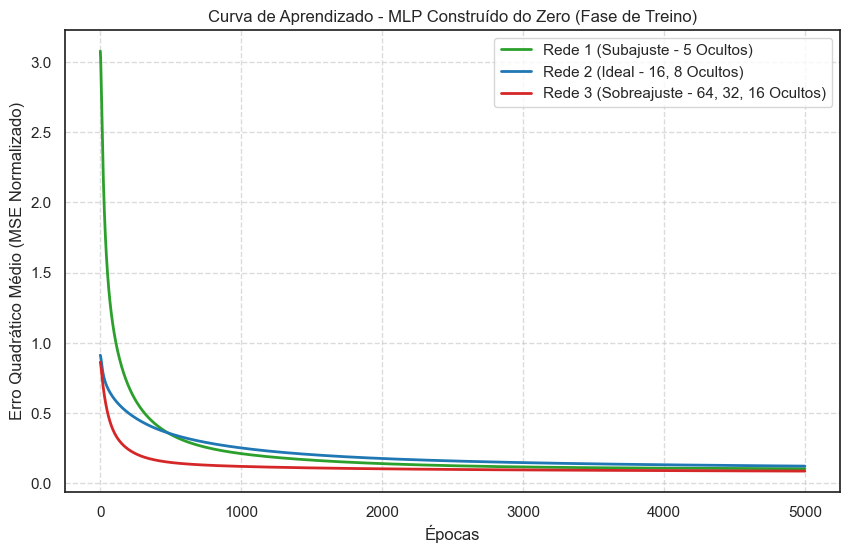


             TABELA DE PREVISÕES: 10 CARROS DESCONHECIDOS


,Linha CSV,Preço Real,Rede 1 (Rasa),Erro R1,Rede 2 (Ideal),Erro R2,Rede 3 (Profunda),Erro R3
0,399,"6,541.00","6,989.85",448.85,"6,665.17",124.17,"7,453.73",912.73
1,7247,"10,424.00","11,084.83",660.83,"11,128.34",704.34,"11,479.73","1,055.73"
2,6406,"3,458.00","3,721.44",263.44,"3,315.32",142.68,"3,966.94",508.94
3,882,"8,817.00","8,310.26",506.74,"9,162.57",345.57,"8,476.13",340.87
4,3565,"5,789.00","5,949.23",160.23,"5,704.83",84.17,"6,183.42",394.42
5,4285,"7,315.00","6,325.67",989.33,"7,408.17",93.17,"6,285.88","1,029.12"
6,1179,"9,741.00","10,402.70",661.70,"11,110.47","1,369.47","10,199.71",458.71
7,5448,"2,410.00","3,716.30","1,306.30","3,451.67","1,041.67","3,626.33","1,216.33"
8,4244,"8,345.00","5,644.33","2,700.67","5,449.50","2,895.50","5,898.24","2,446.76"
9,5218,"10,946.00","11,597.34",651.34,"11,904.90",958.90,"11,355.23",409.23



VEREDITO LOCAL: MÉDIA DE ERRO NESTES 10 CARROS
Rede 1 (Subajuste)   : Errou em média R$ 834.94
Rede 2 (Ideal)       : Errou em média R$ 775.96
Rede 3 (Sobreajuste) : Errou em média R$ 877.28


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# BLOCO 1: Pré-processamento Manual (Sem sklearn)
# ---------------------------------------------------------

# Leia o CSV (Ajuste o diretório caso seja necessário)
df = pd.read_csv('car_price_dataset.csv')

# Mapeamento do Tipo_Combustivel
fuel_mapping = {'Petrol': 0, 'Diesel': 1, 'Electric': 2, 'Hybrid': 3}
df['Fuel_Type'] = df['Fuel_Type'].map(fuel_mapping)

# Separar X e y. Usando as colunas disponíveis (substituindo Cavalos por Portas)
X = df[['Year', 'Engine_Size', 'Fuel_Type', 'Mileage', 'Owner_Count', 'Doors']].values
y = df['Price'].values.reshape(-1, 1)

# Normalização Z-Score pura (Numpy) para X
medias = np.mean(X, axis=0)
desvios = np.std(X, axis=0)
desvios[desvios == 0] = 1e-8 # Evitar divisão por zero
X_norm = (X - medias) / desvios

# Normalizar o Y (Recomendado para estabilidade do backprop)
media_y = np.mean(y)
desvio_y = np.std(y)
y_norm = (y - media_y) / desvio_y

# Embaralhar e dividir os dados (Treino 80%, Teste 20%)
np.random.seed(42)
indices = np.random.permutation(len(X_norm))
corte = int(0.8 * len(X_norm))

idx_treino, idx_teste = indices[:corte], indices[corte:]

X_treino, X_teste = X_norm[idx_treino], X_norm[idx_teste]
y_treino, y_teste = y_norm[idx_treino], y_norm[idx_teste]


# ---------------------------------------------------------
# BLOCO 2: A Classe da Rede Neural (Atualizada para ReLU)
# ---------------------------------------------------------
class RedeNeuralNumpy:
    def __init__(self, topologia, taxa_aprendizado=0.001, momentum=0.8):
        self.topologia = topologia
        self.lr = taxa_aprendizado
        self.momentum = momentum
        self.pesos = []
        self.vieses = []
        self.v_pesos = [] # Velocidade do momentum para pesos
        self.v_vieses = [] # Velocidade do momentum para vieses
        
        # Inicialização "He" extremamente recomendada para ativações ReLU
        for i in range(len(topologia) - 1):
            W = np.random.randn(topologia[i], topologia[i+1]) * np.sqrt(2. / topologia[i])
            b = np.zeros((1, topologia[i+1]))
            self.pesos.append(W)
            self.vieses.append(b)
            self.v_pesos.append(np.zeros_like(W))
            self.v_vieses.append(np.zeros_like(b))

    def _relu(self, z):
        # Substitui a Sigmoid para evitar o problema do desvanecimento do gradiente
        return np.maximum(0, z)
    
    def _derivada_relu(self, a):
        # Retorna 1 para valores maiores que zero e 0 para os demais
        return (a > 0).astype(float)

    def forward(self, X):
        ativacoes = [X]
        # Camadas ocultas (Ativação ReLU)
        for i in range(len(self.pesos) - 1):
            z = np.dot(ativacoes[-1], self.pesos[i]) + self.vieses[i]
            a = self._relu(z)
            ativacoes.append(a)
            
        # Camada de saída (Linear, sem ativação, para tarefas de regressão numérica)
        z_saida = np.dot(ativacoes[-1], self.pesos[-1]) + self.vieses[-1]
        ativacoes.append(z_saida)
        return ativacoes

    def backward(self, ativacoes, y_verdadeiro):
        m = y_verdadeiro.shape[0]
        
        # Erro da camada linear de saída: Derivada de z é 1 -> Delta_L = (A_L - Y)
        delta = (ativacoes[-1] - y_verdadeiro)
        
        grad_pesos = []
        grad_vieses = []
        
        # Gradientes da camada de saída
        grad_W = np.dot(ativacoes[-2].T, delta) / m
        grad_b = np.sum(delta, axis=0, keepdims=True) / m
        grad_pesos.append(grad_W)
        grad_vieses.append(grad_b)
        
        # Backpropagation das camadas ocultas recalculado com base na ReLU
        for i in range(len(self.pesos) - 2, -1, -1):
            delta = np.dot(delta, self.pesos[i+1].T) * self._derivada_relu(ativacoes[i+1])
            grad_W = np.dot(ativacoes[i].T, delta) / m
            grad_b = np.sum(delta, axis=0, keepdims=True) / m
            grad_pesos.insert(0, grad_W)
            grad_vieses.insert(0, grad_b)
            
        # Atualização de Pesos com fator Momentum
        for i in range(len(self.pesos)):
            self.v_pesos[i] = (self.momentum * self.v_pesos[i]) + (self.lr * grad_pesos[i])
            self.v_vieses[i] = (self.momentum * self.v_vieses[i]) + (self.lr * grad_vieses[i])
            
            self.pesos[i] -= self.v_pesos[i]
            self.vieses[i] -= self.v_vieses[i]
            
    def treinar(self, X, y, epocas):
        historico_mse = []
        for _ in range(epocas):
            ativacoes = self.forward(X)
            self.backward(ativacoes, y)
            
            # Cálculo e registro do Mean Squared Error (MSE)
            mse = np.mean((ativacoes[-1] - y) ** 2)
            historico_mse.append(mse)
        return historico_mse


# ---------------------------------------------------------
# BLOCO 3: O Experimento de Topologias (Ajuste Fino)
# ---------------------------------------------------------
# Temos 6 features de input e 1 de output (Preço).
topologia_rede1 = [6, 5, 1] 
topologia_rede2 = [6, 16, 8, 1]
topologia_rede3 = [6, 64, 32, 16, 1]

epocas = 5000
taxa_aprendizado = 0.001

print("Treinando Rede 1 (Subajuste)...")
rede1 = RedeNeuralNumpy(topologia_rede1, taxa_aprendizado)
hist1 = rede1.treinar(X_treino, y_treino, epocas)

print("Treinando Rede 2 (Ideal)...")
rede2 = RedeNeuralNumpy(topologia_rede2, taxa_aprendizado)
hist2 = rede2.treinar(X_treino, y_treino, epocas)

print("Treinando Rede 3 (Sobreajuste)...")
rede3 = RedeNeuralNumpy(topologia_rede3, taxa_aprendizado)
hist3 = rede3.treinar(X_treino, y_treino, epocas)


# ---------------------------------------------------------
# BLOCO 4: Resultados Visuais e Gráfico de Perda
# ---------------------------------------------------------

def desnormalizar_mse(mse_norm, desvio):
    return mse_norm * (desvio ** 2)

# Previsão nos dados de TESTE e cálculo do Erro Final (MSE Real Desnormalizado)
pred_1 = rede1.forward(X_teste)[-1]
mse1_teste = np.mean((pred_1 - y_teste)**2)
mse1_real = desnormalizar_mse(mse1_teste, desvio_y)

pred_2 = rede2.forward(X_teste)[-1]
mse2_teste = np.mean((pred_2 - y_teste)**2)
mse2_real = desnormalizar_mse(mse2_teste, desvio_y)

pred_3 = rede3.forward(X_teste)[-1]
mse3_teste = np.mean((pred_3 - y_teste)**2)
mse3_real = desnormalizar_mse(mse3_teste, desvio_y)

print("\n-------------------------------------------")
print("--- Resultados Gerais no Conjunto de Teste ---")
print("-------------------------------------------")
print(f"Rede 1 (Subajuste)   - MSE Geral: {mse1_real:,.2f}")
print(f"Rede 2 (Ideal)       - MSE Geral: {mse2_real:,.2f}")
print(f"Rede 3 (Sobreajuste) - MSE Geral: {mse3_real:,.2f}")

# Plotagem da Curva de Aprendizado Combinada
plt.figure(figsize=(10, 6))
plt.plot(hist1, label='Rede 1 (Subajuste - 5 Ocultos)', color='#2ca02c', linewidth=2)
plt.plot(hist2, label='Rede 2 (Ideal - 16, 8 Ocultos)', color='#1f77b4', linewidth=2)
plt.plot(hist3, label='Rede 3 (Sobreajuste - 64, 32, 16 Ocultos)', color='#d62728', linewidth=2)

plt.title('Curva de Aprendizado - MLP Construído do Zero (Fase de Treino)')
plt.xlabel('Épocas')
plt.ylabel('Erro Quadrático Médio (MSE Normalizado)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# ---------------------------------------------------------
# BLOCO 5: Teste Prático Comparativo (10 Carros Novos) - ATUALIZADO
# ---------------------------------------------------------
qtd_carros = 10
resultados = []

for i in range(qtd_carros):
    # AQUI: Pegamos o índice real da linha do dataset original (CSV)
    linha_original = idx_teste[i]
    
    carro_x = X_teste[i].reshape(1, -1)
    
    preco_real_norm = y_teste[i][0]
    preco_real = (preco_real_norm * desvio_y) + media_y
    
    # Previsões individuais nas 3 redes
    prev_norm_1 = rede1.forward(carro_x)[-1][0][0]
    prev_norm_2 = rede2.forward(carro_x)[-1][0][0]
    prev_norm_3 = rede3.forward(carro_x)[-1][0][0]
    
    # Processo de desnormalização individual
    prev_1 = (prev_norm_1 * desvio_y) + media_y
    prev_2 = (prev_norm_2 * desvio_y) + media_y
    prev_3 = (prev_norm_3 * desvio_y) + media_y
    
    resultados.append({
        "Linha CSV": linha_original, # Adicionamos a linha exata do dataset aqui!
        "Preço Real": preco_real,
        "Rede 1 (Rasa)": prev_1,
        "Erro R1": abs(preco_real - prev_1),
        "Rede 2 (Ideal)": prev_2,
        "Erro R2": abs(preco_real - prev_2),
        "Rede 3 (Profunda)": prev_3,
        "Erro R3": abs(preco_real - prev_3)
    })

df_resultados = pd.DataFrame(resultados)

# Formatação visual da tabela em formato monetário padrão
formatacao_moeda = "{:,.2f}".format
colunas_dinheiro = ["Preço Real", "Rede 1 (Rasa)", "Erro R1", "Rede 2 (Ideal)", "Erro R2", "Rede 3 (Profunda)", "Erro R3"]

for col in colunas_dinheiro:
    df_resultados[col] = df_resultados[col].apply(formatacao_moeda)

print("\n" + "="*95)
print("             TABELA DE PREVISÕES: 10 CARROS DESCONHECIDOS")
print("="*95)
display(df_resultados)

# Veredito de desempenho local com base nas amostras inéditas
erro_medio_1 = sum([r["Erro R1"] for r in resultados]) / qtd_carros
erro_medio_2 = sum([r["Erro R2"] for r in resultados]) / qtd_carros
erro_medio_3 = sum([r["Erro R3"] for r in resultados]) / qtd_carros

print("\n" + "=" * 50)
print("VEREDITO LOCAL: MÉDIA DE ERRO NESTES 10 CARROS")
print("=" * 50)
print(f"Rede 1 (Subajuste)   : Errou em média R$ {erro_medio_1:,.2f}")
print(f"Rede 2 (Ideal)       : Errou em média R$ {erro_medio_2:,.2f}")
print(f"Rede 3 (Sobreajuste) : Errou em média R$ {erro_medio_3:,.2f}")
print("=" * 50)

Treinando Rede 1 (Subajuste)...
Treinando Rede 2 (Ideal)...
Treinando Rede 3 (Sobreajuste)...

-------------------------------------------
--- Resultados Gerais no Conjunto de Teste ---
-------------------------------------------
Rede 1 (Subajuste)   - MSE Geral: 506,462.80
Rede 2 (Ideal)       - MSE Geral: 515,631.30
Rede 3 (Sobreajuste) - MSE Geral: 636,083.71


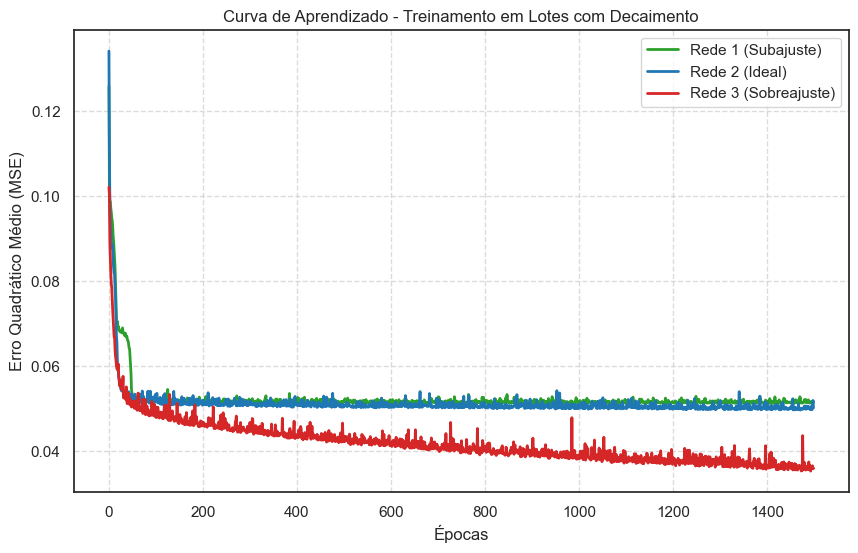


             TABELA DE PREVISÕES: 10 CARROS DESCONHECIDOS


,Linha CSV,Preço Real,Rede 1 (Rasa),Erro R1,Rede 2 (Ideal),Erro R2,Rede 3 (Profunda),Erro R3
0,399,"6,541.00","6,989.42",448.42,"7,044.17",503.17,"7,539.43",998.43
1,7247,"10,424.00","10,982.09",558.09,"10,888.72",464.72,"10,595.06",171.06
2,6406,"3,458.00","3,919.03",461.03,"4,342.31",884.31,"3,701.72",243.72
3,882,"8,817.00","7,832.66",984.34,"7,751.78","1,065.22","7,676.67","1,140.33"
4,3565,"5,789.00","6,322.54",533.54,"5,818.50",29.50,"5,789.58",0.58
5,4285,"7,315.00","7,734.00",419.00,"7,886.39",571.39,"7,904.67",589.67
6,1179,"9,741.00","10,299.18",558.18,"10,151.54",410.54,"10,264.86",523.86
7,5448,"2,410.00","3,023.64",613.64,"3,180.55",770.55,"2,578.41",168.41
8,4244,"8,345.00","7,240.86","1,104.14","7,267.00","1,078.00","7,199.42","1,145.58"
9,5218,"10,946.00","11,532.39",586.39,"11,391.37",445.37,"11,630.59",684.59



VEREDITO LOCAL: MÉDIA DE ERRO NESTES 10 CARROS
Rede 1 (Subajuste)   : Errou em média R$ 626.68
Rede 2 (Ideal)       : Errou em média R$ 622.28
Rede 3 (Sobreajuste) : Errou em média R$ 566.62


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# =========================================================
# BLOCO 1: Pré-processamento Manual (Sem sklearn)
# =========================================================
df = pd.read_csv('car_price_dataset.csv')

# Mapeamento do Tipo_Combustivel
fuel_mapping = {'Petrol': 0, 'Diesel': 1, 'Electric': 2, 'Hybrid': 3}
df['Fuel_Type'] = df['Fuel_Type'].map(fuel_mapping)

# Separar X e y
X = df[['Year', 'Engine_Size', 'Fuel_Type', 'Mileage', 'Owner_Count', 'Doors']].values
y = df['Price'].values.reshape(-1, 1)

# Normalização Z-Score pura (Numpy)
medias = np.mean(X, axis=0)
desvios = np.std(X, axis=0)
desvios[desvios == 0] = 1e-8 
X_norm = (X - medias) / desvios

media_y = np.mean(y)
desvio_y = np.std(y)
y_norm = (y - media_y) / desvio_y

# Embaralhar e dividir os dados (Treino 80%, Teste 20%)
np.random.seed(42)
indices = np.random.permutation(len(X_norm))
corte = int(0.8 * len(X_norm))

idx_treino, idx_teste = indices[:corte], indices[corte:]

X_treino, X_teste = X_norm[idx_treino], X_norm[idx_teste]
y_treino, y_teste = y_norm[idx_treino], y_norm[idx_teste]


# =========================================================
# BLOCO 2: A Classe da Rede Neural (Com Lotes e Decaimento)
# =========================================================
class RedeNeuralNumpy:
    def __init__(self, topologia, taxa_aprendizado=0.005, momentum=0.9):
        self.topologia = topologia
        self.lr_inicial = taxa_aprendizado # Guarda a taxa original para o cálculo do decaimento
        self.lr = taxa_aprendizado
        self.momentum = momentum
        self.pesos = []
        self.vieses = []
        self.v_pesos = [] 
        self.v_vieses = [] 
        
        # Inicialização de pesos "He" para ativação ReLU
        for i in range(len(topologia) - 1):
            W = np.random.randn(topologia[i], topologia[i+1]) * np.sqrt(2. / topologia[i])
            b = np.zeros((1, topologia[i+1]))
            self.pesos.append(W)
            self.vieses.append(b)
            self.v_pesos.append(np.zeros_like(W))
            self.v_vieses.append(np.zeros_like(b))

    def _relu(self, z):
        return np.maximum(0, z)
    
    def _derivada_relu(self, a):
        return (a > 0).astype(float)

    def forward(self, X):
        ativacoes = [X]
        for i in range(len(self.pesos) - 1):
            z = np.dot(ativacoes[-1], self.pesos[i]) + self.vieses[i]
            a = self._relu(z)
            ativacoes.append(a)
            
        z_saida = np.dot(ativacoes[-1], self.pesos[-1]) + self.vieses[-1]
        ativacoes.append(z_saida)
        return ativacoes

    def backward(self, ativacoes, y_verdadeiro):
        m = y_verdadeiro.shape[0]
        delta = (ativacoes[-1] - y_verdadeiro)
        
        grad_pesos = []
        grad_vieses = []
        
        grad_W = np.dot(ativacoes[-2].T, delta) / m
        grad_b = np.sum(delta, axis=0, keepdims=True) / m
        grad_pesos.append(grad_W)
        grad_vieses.append(grad_b)
        
        for i in range(len(self.pesos) - 2, -1, -1):
            delta = np.dot(delta, self.pesos[i+1].T) * self._derivada_relu(ativacoes[i+1])
            grad_W = np.dot(ativacoes[i].T, delta) / m
            grad_b = np.sum(delta, axis=0, keepdims=True) / m
            grad_pesos.insert(0, grad_W)
            grad_vieses.insert(0, grad_b)
            
        for i in range(len(self.pesos)):
            self.v_pesos[i] = (self.momentum * self.v_pesos[i]) + (self.lr * grad_pesos[i])
            self.v_vieses[i] = (self.momentum * self.v_vieses[i]) + (self.lr * grad_vieses[i])
            
            self.pesos[i] -= self.v_pesos[i]
            self.vieses[i] -= self.v_vieses[i]
            
    def treinar(self, X, y, epocas, tamanho_lote=32):
        historico_mse = []
        m_total = X.shape[0]
        
        for epoca in range(epocas):
            # MUDANÇA 1: Aplica o Decaimento da Taxa de Aprendizado
            self.lr = self.lr_inicial * (0.95 ** (epoca / 500))
            
            # MUDANÇA 2: Embaralha os dados para criar os Lotes
            indices = np.random.permutation(m_total)
            X_embaralhado = X[indices]
            y_embaralhado = y[indices]
            
            # MUDANÇA 3: Treina de 32 em 32 carros
            for i in range(0, m_total, tamanho_lote):
                X_lote = X_embaralhado[i : i + tamanho_lote]
                y_lote = y_embaralhado[i : i + tamanho_lote]
                
                ativacoes = self.forward(X_lote)
                self.backward(ativacoes, y_lote)
                
            # Calcula o erro no final da época
            ativacoes_totais = self.forward(X)
            mse = np.mean((ativacoes_totais[-1] - y) ** 2)
            historico_mse.append(mse)
            
        return historico_mse


# =========================================================
# BLOCO 3: O Experimento de Topologias
# =========================================================
topologia_rede1 = [6, 5, 1] 
topologia_rede2 = [6, 16, 8, 1]
topologia_rede3 = [6, 64, 32, 16, 1]

epocas = 1500               # 1500 épocas agora rendem muito mais por causa dos lotes
taxa_aprendizado = 0.005
tamanho_do_lote = 32

print("Treinando Rede 1 (Subajuste)...")
rede1 = RedeNeuralNumpy(topologia_rede1, taxa_aprendizado)
hist1 = rede1.treinar(X_treino, y_treino, epocas, tamanho_do_lote)

print("Treinando Rede 2 (Ideal)...")
rede2 = RedeNeuralNumpy(topologia_rede2, taxa_aprendizado)
hist2 = rede2.treinar(X_treino, y_treino, epocas, tamanho_do_lote)

print("Treinando Rede 3 (Sobreajuste)...")
rede3 = RedeNeuralNumpy(topologia_rede3, taxa_aprendizado)
hist3 = rede3.treinar(X_treino, y_treino, epocas, tamanho_do_lote)


# =========================================================
# BLOCO 4: Resultados Visuais
# =========================================================
def desnormalizar_mse(mse_norm, desvio):
    return mse_norm * (desvio ** 2)

pred_1 = rede1.forward(X_teste)[-1]
mse1_teste = np.mean((pred_1 - y_teste)**2)
mse1_real = desnormalizar_mse(mse1_teste, desvio_y)

pred_2 = rede2.forward(X_teste)[-1]
mse2_teste = np.mean((pred_2 - y_teste)**2)
mse2_real = desnormalizar_mse(mse2_teste, desvio_y)

pred_3 = rede3.forward(X_teste)[-1]
mse3_teste = np.mean((pred_3 - y_teste)**2)
mse3_real = desnormalizar_mse(mse3_teste, desvio_y)

print("\n-------------------------------------------")
print("--- Resultados Gerais no Conjunto de Teste ---")
print("-------------------------------------------")
print(f"Rede 1 (Subajuste)   - MSE Geral: {mse1_real:,.2f}")
print(f"Rede 2 (Ideal)       - MSE Geral: {mse2_real:,.2f}")
print(f"Rede 3 (Sobreajuste) - MSE Geral: {mse3_real:,.2f}")

plt.figure(figsize=(10, 6))
plt.plot(hist1, label='Rede 1 (Subajuste)', color='#2ca02c', linewidth=2)
plt.plot(hist2, label='Rede 2 (Ideal)', color='#1f77b4', linewidth=2)
plt.plot(hist3, label='Rede 3 (Sobreajuste)', color='#d62728', linewidth=2)
plt.title('Curva de Aprendizado - Treinamento em Lotes com Decaimento')
plt.xlabel('Épocas')
plt.ylabel('Erro Quadrático Médio (MSE)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# =========================================================
# BLOCO 5: Tabela de Teste (Com a Linha do CSV preservada)
# =========================================================
qtd_carros = 10
resultados = []

for i in range(qtd_carros):
    # Puxa o índice exato de onde esse carro estava na tabela original
    linha_original = idx_teste[i]
    
    carro_x = X_teste[i].reshape(1, -1)
    
    preco_real_norm = y_teste[i][0]
    preco_real = (preco_real_norm * desvio_y) + media_y
    
    prev_norm_1 = rede1.forward(carro_x)[-1][0][0]
    prev_norm_2 = rede2.forward(carro_x)[-1][0][0]
    prev_norm_3 = rede3.forward(carro_x)[-1][0][0]
    
    prev_1 = (prev_norm_1 * desvio_y) + media_y
    prev_2 = (prev_norm_2 * desvio_y) + media_y
    prev_3 = (prev_norm_3 * desvio_y) + media_y
    
    resultados.append({
        "Linha CSV": linha_original,
        "Preço Real": preco_real,
        "Rede 1 (Rasa)": prev_1,
        "Erro R1": abs(preco_real - prev_1),
        "Rede 2 (Ideal)": prev_2,
        "Erro R2": abs(preco_real - prev_2),
        "Rede 3 (Profunda)": prev_3,
        "Erro R3": abs(preco_real - prev_3)
    })

df_resultados = pd.DataFrame(resultados)

formatacao_moeda = "{:,.2f}".format
colunas_dinheiro = ["Preço Real", "Rede 1 (Rasa)", "Erro R1", "Rede 2 (Ideal)", "Erro R2", "Rede 3 (Profunda)", "Erro R3"]

for col in colunas_dinheiro:
    df_resultados[col] = df_resultados[col].apply(formatacao_moeda)

print("\n" + "="*95)
print("             TABELA DE PREVISÕES: 10 CARROS DESCONHECIDOS")
print("="*95)
display(df_resultados)

erro_medio_1 = sum([r["Erro R1"] for r in resultados]) / qtd_carros
erro_medio_2 = sum([r["Erro R2"] for r in resultados]) / qtd_carros
erro_medio_3 = sum([r["Erro R3"] for r in resultados]) / qtd_carros

print("\n" + "=" * 50)
print("VEREDITO LOCAL: MÉDIA DE ERRO NESTES 10 CARROS")
print("=" * 50)
print(f"Rede 1 (Subajuste)   : Errou em média R$ {erro_medio_1:,.2f}")
print(f"Rede 2 (Ideal)       : Errou em média R$ {erro_medio_2:,.2f}")
print(f"Rede 3 (Sobreajuste) : Errou em média R$ {erro_medio_3:,.2f}")
print("=" * 50)